<a href="https://colab.research.google.com/github/hellothurein/WQU-MScFE-690-Portfolio-Optimization/blob/main/8_selected_ETF_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf


def build_etf_feature_pipeline(tickers, start_date, end_date, lookback=20):
    """Downloads historical ETF data and creates a multi-dimensional, continuous

    feature space suitable for Deep Reinforcement Learning agents.
    """
    print(f"Downloading data for: {tickers}")
    # Download Adjusted Close prices
    raw_data = yf.download(tickers, start=start_date, end=end_date)[
        "Close"
    ]

    # Handle structural market holidays
    raw_data = raw_data.ffill().dropna()

    # Master list to hold individual asset
    processed_assets = []

    for ticker in tickers:
        asset_df = pd.DataFrame(index=raw_data.index)
        asset_df["price"] = raw_data[ticker]

        # 1. Continuous Log Returns
        asset_df["log_return"] = np.log(
            asset_df["price"] / asset_df["price"].shift(1)
        )

        # 2. Multi-Horizon Log Returns
        asset_df["log_return_5d"] = np.log(
            asset_df["price"] / asset_df["price"].shift(5)
        )
        asset_df["log_return_21d"] = np.log(
            asset_df["price"] / asset_df["price"].shift(21)
        )

        # 3. Rolling Volatility
        asset_df["rolling_vol"] = (
            asset_df["log_return"].rolling(window=lookback).std()
            * np.sqrt(252)
        )

        # 4. Moving Average Ratio
        asset_df["sma_ratio"] = (
            asset_df["price"]
            / asset_df["price"].rolling(window=lookback).mean()
        )

        # 5. Continuous Relative Strength Index
        delta = asset_df["price"].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        asset_df["rsi"] = 100 - (100 / (1 + rs))

        asset_df["rsi"] = asset_df["rsi"] / 100.0

        # Create a MultiIndex column structure
        asset_df.columns = pd.MultiIndex.from_product(
            [[ticker], asset_df.columns]
        )
        processed_assets.append(asset_df)

    # Concatenate all asset columns horizontally
    final_df = pd.concat(processed_assets, axis=1)

    # 6. Global Feature: Rolling Cross-Asset Correlation Vector

    print("Computing rolling cross-asset correlations...")
    log_returns_df = raw_data.pct_change().apply(np.log1p)

    correlation_features = []
    for i in range(len(final_df)):
        if i < lookback:
            correlation_features.append(
                np.zeros(int(len(tickers) * (len(tickers) - 1) / 2))
            )
            continue
        # Slice the lookback window matrix
        window = log_returns_df.iloc[i - lookback + 1 : i + 1]
        corr_matrix = window.corr()
        # Extract lower triangle elements
        lower_tri = corr_matrix.values[np.tril_indices(len(tickers), k=-1)]
        correlation_features.append(lower_tri)

    # Convert correlation list to a structured DataFrame
    corr_cols = pd.MultiIndex.from_product(
        [["GLOBAL"], [f"corr_{idx}" for idx in range(len(lower_tri))]]
    )
    corr_df = pd.DataFrame(
        correlation_features, index=final_df.index, columns=corr_cols
    )

    # Combine asset-specific features
    feature_matrix = pd.concat([final_df, corr_df], axis=1)

    # Clean up lookback alignment NaNs
    feature_matrix = feature_matrix.iloc[lookback:].dropna()

    return feature_matrix


# --- EXECUTION PIPELINE ---
if __name__ == "__main__":

    portfolio_tickers = [
        "SPY",
        "IWM",
        "VGK",
        "EEM",
        "AGG",
        "TLT",
        "GLD",
        "VNQ",
    ]

    # Data boundaries aligning with current 2026 data timelines
    START_DATE = "2015-01-01"
    END_DATE = "2026-06-01"


    df_features = build_etf_feature_pipeline(
        portfolio_tickers, START_DATE, END_DATE
    )

    print("\n--- Feature Engineering Pipeline Complete ---")
    print(f"Total Trading Days Shape: {df_features.shape}")
    print(f"Sample Structure:\n{df_features.head(2)}")


    df_features.to_csv("etf_drl_state_space.csv")
    print("\nFile saved successfully as 'etf_drl_state_space.csv'")

/tmp/ipykernel_734/3546322577.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)[
[*********************100%***********************]  8 of 8 completed


Computing rolling cross-asset correlations...

--- Feature Engineering Pipeline Complete ---
Total Trading Days Shape: (2847, 84)
Sample Structure:
                   SPY                                                      \
                 price log_return log_return_5d log_return_21d rolling_vol   
Date                                                                         
2015-02-03  169.200470   0.014357      0.010305      -0.002877    0.170625   
2015-02-04  168.556229  -0.003815      0.019397       0.011534    0.167278   

                                       IWM                           ...  \
           sma_ratio       rsi       price log_return log_return_5d  ...   
Date                                                                 ...   
2015-02-03  1.011241  0.551415  102.474167   0.017742      0.001347  ...   
2015-02-04  1.006337  0.560605  102.094780  -0.003709      0.014632  ...   

              GLOBAL                                                    \
      

In [2]:

print("="*50)
print(f"1. MATRIX SHAPE: {df_features.shape}")
print(f"   Date Range: From {df_features.index[0].date()} to {df_features.index[-1].date()}")
print("="*50)

print("\n2. MISSING VALUES CHECK:")
nan_counts = df_features.isna().sum().sum()
print(f"   Total NaN values remaining in matrix: {nan_counts}")
print("="*50)

print("\n3. MULTI-INDEX STRUCTURE:")
print(f"   Asset Classes Found: {list(df_features.columns.levels[0])}")
print("="*50)

print("\n4. SAMPLE FEATURE VALUES (First 2 Rows for SPY):")
print(df_features['SPY'].head(2))
print("="*50)

1. MATRIX SHAPE: (2847, 84)
   Date Range: From 2015-02-03 to 2026-05-29

2. MISSING VALUES CHECK:
   Total NaN values remaining in matrix: 0

3. MULTI-INDEX STRUCTURE:
   Asset Classes Found: ['AGG', 'EEM', 'GLD', 'GLOBAL', 'IWM', 'SPY', 'TLT', 'VGK', 'VNQ']

4. SAMPLE FEATURE VALUES (First 2 Rows for SPY):
                 price  log_return  log_return_5d  log_return_21d  \
Date                                                                
2015-02-03  169.200470    0.014357       0.010305       -0.002877   
2015-02-04  168.556229   -0.003815       0.019397        0.011534   

            rolling_vol  sma_ratio       rsi  
Date                                          
2015-02-03     0.170625   1.011241  0.551415  
2015-02-04     0.167278   1.006337  0.560605  


In [4]:

import numpy as np
import gymnasium as gym
from gymnasium import spaces
from collections import deque


class MultiAssetPortfolioEnv(gym.Env):


    metadata = {"render.modes": ["human"]}

    def __init__(self, df, tickers, window_size=20, penalty_coefficient=0.1, transaction_cost=0.001):
        super(MultiAssetPortfolioEnv, self).__init__()

        self.df = df
        self.tickers = tickers
        self.num_assets = len(tickers)
        self.window_size = window_size
        self.penalty_coefficient = penalty_coefficient
        self.transaction_cost = transaction_cost

        # --- State Space ---
        self.features = df.values
        self.total_steps = len(self.df) - 1

        # Extract per-asset log return columns from MultiIndex
        self.return_col_indices = []
        for ticker in tickers:
            for i, col in enumerate(df.columns):
                if ticker in str(col) and 'log_return' in str(col) and '5d' not in str(col) and '21d' not in str(col):
                    self.return_col_indices.append(i)
                    break

        # --- Gym Spaces ---
        self.action_space = spaces.Box(
            low=0, high=1, shape=(self.num_assets,), dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(df.shape[1],), dtype=np.float32
        )

        # --- Internal State  ---
        self.current_step = 0
        self.last_weights = np.ones(self.num_assets) / self.num_assets
        self.portfolio_return_history = deque(maxlen=self.window_size)


    #  FIX 1A: reset()

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0
        self.last_weights = np.ones(self.num_assets) / self.num_assets


        self.portfolio_return_history = deque(maxlen=self.window_size)

        obs = self.features[self.current_step].astype(np.float32)
        info = {}
        return obs, info


    #  FIX 1B: step()

    def step(self, action):

        # 1. Softmax normalization
        exp_actions = np.exp(action - np.max(action))
        weights = exp_actions / np.sum(exp_actions)

        # 2. Transaction cost
        turnover = np.sum(np.abs(weights - self.last_weights))
        turnover_cost = self.transaction_cost * turnover

        # 3. Realized asset log returns at t+1
        next_step_idx = self.current_step + 1
        asset_returns = self.features[next_step_idx][self.return_col_indices]

        # 4. Gross and net portfolio return
        gross_return = np.dot(weights, asset_returns)
        net_return = gross_return - turnover_cost

        # 5. Append to rolling history for CVaR computation
        self.portfolio_return_history.append(net_return)

        # 6. True 95% CVaR (Expected Shortfall) penalty
        if len(self.portfolio_return_history) >= self.window_size:
            window_arr = np.array(self.portfolio_return_history)
            var_95 = np.percentile(window_arr, 5)
            tail_losses = window_arr[window_arr <= var_95]
            cvar_penalty = abs(np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0
        else:
            cvar_penalty = 0.0

        # 7. CVaR-penalized reward
        reward = net_return - (self.penalty_coefficient * cvar_penalty)

        # 8. Advance step and check terminal condition
        self.last_weights = weights
        self.current_step += 1
        done = self.current_step >= (self.total_steps - 1)
        truncated = False

        # 9. Next observation
        next_obs = self.features[self.current_step].astype(np.float32)


        # FIX 1B: Complete info dict

        info = {
            "realized_return": net_return,
            "turnover_cost": turnover_cost,
            "weights": weights.copy(),
            "gross_return": gross_return,
            "cvar_penalty": cvar_penalty,
            "reward": reward,
        }

        return next_obs, reward, done, truncated, info

In [7]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 16.7 MB/s eta 0:00:00


In [8]:
# 1. Split data matrices by date boundaries
train_df = df_features.loc[:'2023-12-31']
test_df = df_features.loc['2024-01-01':]

print("="*50)
print(f"Training Framework Set (In-Sample): {train_df.shape} rows (2015-2023)")
print(f"Evaluation Framework Set (Out-of-Sample): {test_df.shape} rows (2024-2026)")
print("="*50)

# 2. Instantiate individual environments
train_env = MultiAssetPortfolioEnv(df=train_df, tickers=portfolio_tickers)
test_env = MultiAssetPortfolioEnv(df=test_df, tickers=portfolio_tickers)

Training Framework Set (In-Sample): (2243, 84) rows (2015-2023)
Evaluation Framework Set (Out-of-Sample): (604, 84) rows (2024-2026)


In [9]:

from stable_baselines3 import PPO
import os

print("="*50)
print("INITIALIZING PPO ACTOR-CRITIC AGENT")
print("="*50)

# Initialize PPO
model = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    verbose=1,
    tensorboard_log="./ppo_portfolio_tensorboard/"
)

print("\nCommencing Deep Policy training over 500,000 environmental timesteps...")
print("This allows the agent to navigate hundreds of simulated market cycles...\n")

# model.learn(total_timesteps=500000)
model.learn(total_timesteps=2000000)

print("\n"+"="*50)
print("POLICY CONVERGENCE VERIFIED: SAVING TRAINED WEIGHTS")
print("="*50)
model.save("ppo_cvar_portfolio_agent")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


INITIALIZING PPO ACTOR-CRITIC AGENT
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Commencing Deep Policy training over 500,000 environmental timesteps...
This allows the agent to navigate hundreds of simulated market cycles...

Logging to ./ppo_portfolio_tensorboard/PPO_1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    value_loss           | 8.04e-05   |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.24e+03   |
|    ep_rew_mean          | -2.41      |
| time/                   |            |
|    fps                  | 638        |
|    iterations           | 751        |
|    time_elapsed         | 2407       |
|    total_timesteps      | 1538048    |
| train/                  |            |
|    approx_kl            | 0.03577555 |
|    clip_fraction        | 0.295      |
|    clip_range           | 0.2        |
|    entropy_loss         | -5.06      |
|    explained_variance   | 0.987      |
|    learning_rate        | 0.0003     |
|    loss                 | 0.000624   |
|    n_updates            | 7500       |
|    policy_gradient_loss | 0.0044     |
|    std                  | 0.462      |
|    value_loss           | 8.89e-05   |
------

In [10]:

# 1. RUN THE OUT-OF-SAMPLE BACKTEST LOOP

print("Launching Out-of-Sample Evaluation Pipeline (2024-2026)...")

# Reset the testing environment
obs, info = test_env.reset()
done = False

# Analytical lists to log daily portfolio metrics
realized_strategy_returns = []
realized_turnover_costs = []
allocated_weight_history = []
dates_history = []

# Get the actual trading dates for the test period
test_dates = test_df.index

while not done:
    # Capture the exact date of the current step for tracking
    current_date = test_dates[test_env.current_step]
    dates_history.append(current_date)

    # Use the optimized model to predict the ideal allocation vector deterministically
    action, _states = model.predict(obs, deterministic=True)

    # Progress the step inside the test environment
    obs, reward, done, truncated, info = test_env.step(action)

    # Store daily historical feedback profiles
    realized_strategy_returns.append(info['realized_return'])
    realized_turnover_costs.append(info['turnover_cost'])
    allocated_weight_history.append(info['weights'])

print(f"Backtest successfully completed over {len(realized_strategy_returns)} unseen trading days.")


# 2. COMPUTE INSTITUTIONAL PERFORMANCE METRICS

returns_series = pd.Series(realized_strategy_returns, index=dates_history)

# Total Cumulative Growth Profile
cumulative_returns = np.exp(np.log1p(returns_series).cumsum()) - 1
total_profit_pct = cumulative_returns.iloc[-1] * 100

# Annualized Performance
mean_return = returns_series.mean()
annualized_return_pct = (mean_return * 252) * 100
annualized_volatility_pct = (returns_series.std() * np.sqrt(252)) * 100

# Traditional Sharpe Ratio
sharpe_ratio = (mean_return / (returns_series.std() + 1e-9)) * np.sqrt(252)

# Tail-Risk Downside Metrics
downside_returns = returns_series[returns_series < 0]
downside_std = downside_returns.std() if len(downside_returns) > 0 else 1e-9
sortino_ratio = (mean_return / (downside_std + 1e-9)) * np.sqrt(252)

# Maximum Drawdown Profile
peak = (cumulative_returns + 1).cummax()
drawdown = ((cumulative_returns + 1) - peak) / peak
max_drawdown_pct = drawdown.min() * 100

# Empirical Daily Value-at-Risk
daily_var_95_pct = np.percentile(returns_series, 5) * 100

# Print the final structured Performance Sheet
print("\n" + "="*60)
print("        INSTITUTIONAL STRATEGY PERFORMANCE REPORT (2024-2026)")
print("="*60)
print(f" Total Out-of-Sample Profit   : {total_profit_pct:.2f}%")
print(f" Annualized Return            : {annualized_return_pct:.2f}%")
print(f" Annualized Volatility        : {annualized_volatility_pct:.2f}%")
print(f" Sharpe Ratio (Risk-Free=0)   : {sharpe_ratio:.2f}")
print(f" Sortino Ratio (Downside Risk): {sortino_ratio:.2f}")
print(f" Maximum Peak-to-Trough DD    : {max_drawdown_pct:.2f}%")
print(f" Historical Daily VaR (95%)   : {daily_var_95_pct:.2f}%")
print("="*60)

Launching Out-of-Sample Evaluation Pipeline (2024-2026)...
Backtest successfully completed over 602 unseen trading days.

        INSTITUTIONAL STRATEGY PERFORMANCE REPORT (2024-2026)
 Total Out-of-Sample Profit   : 32.35%
 Annualized Return            : 12.26%
 Annualized Volatility        : 10.24%
 Sharpe Ratio (Risk-Free=0)   : 1.20
 Sortino Ratio (Downside Risk): 1.61
 Maximum Peak-to-Trough DD    : -10.07%
 Historical Daily VaR (95%)   : -1.03%


Running Markowitz Minimum-Variance backtest (2024–2026)...
Markowitz Sharpe Ratio (OOS): 1.51
Markowitz Total Return  (OOS): 21.81%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


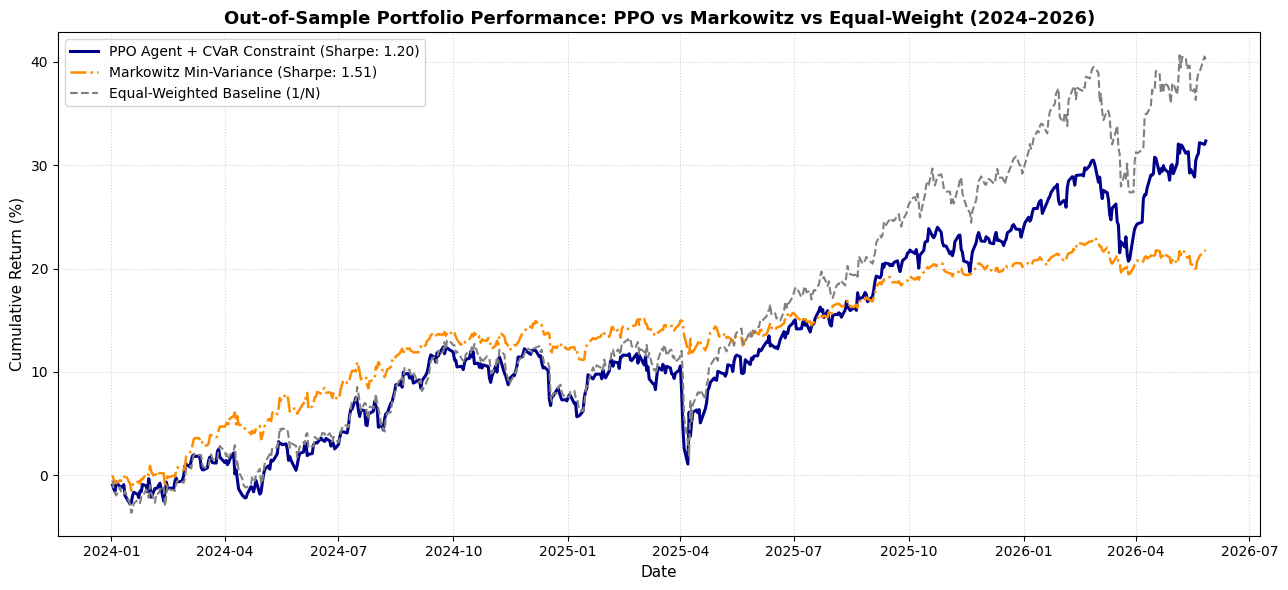

In [11]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#  FIX 2A: Minimum Variance


def compute_minimum_variance_weights(historical_returns):

    cov_matrix = np.cov(historical_returns, rowvar=False)
    num_assets = cov_matrix.shape[0]

    def portfolio_variance(weights):
        return np.dot(weights.T, np.dot(cov_matrix, weights))

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
    bounds = [(0.0, 1.0) for _ in range(num_assets)]
    initial_weights = np.ones(num_assets) / num_assets

    result = minimize(
        portfolio_variance,
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000}
    )

    return result.x if result.success else initial_weights


def backtest_markowitz(raw_log_returns_df, train_end_date, lookback_days=252):

    all_returns = raw_log_returns_df.values
    all_dates = raw_log_returns_df.index

    # Find index where test period starts
    train_end_idx = raw_log_returns_df.index.searchsorted(train_end_date)

    oos_returns = []
    oos_dates = []

    for t in range(train_end_idx, len(all_returns) - 1):
        # Use previous 252 days to estimate covariance
        lookback_data = all_returns[t - lookback_days:t]

        if len(lookback_data) < lookback_days:
            # Not enough history yet
            opt_weights = np.ones(raw_log_returns_df.shape[1]) / raw_log_returns_df.shape[1]
        else:
            opt_weights = compute_minimum_variance_weights(lookback_data)

        # Apply weights to next-day realized returns (t+1)
        next_day_returns = all_returns[t + 1]
        daily_return = np.dot(opt_weights, next_day_returns)
        oos_returns.append(daily_return)
        oos_dates.append(all_dates[t + 1])

    return pd.Series(oos_returns, index=oos_dates, name='Markowitz_MV')



#  FIX 2B: Call the benchmark and align to PPO evaluation period


log_returns_all = pd.DataFrame(
    {ticker: df_features[ticker]['log_return'] for ticker in portfolio_tickers},
    index=df_features.index
)

print("Running Markowitz Minimum-Variance backtest (2024–2026)...")
markowitz_returns = backtest_markowitz(log_returns_all, train_end_date='2023-12-31')

# Align to the exact same dates as the PPO backtest
markowitz_aligned = markowitz_returns.reindex(returns_series.index).fillna(0)
cumulative_markowitz = np.exp(np.log1p(markowitz_aligned).cumsum()) - 1

# Compute Markowitz performance metrics for the legend
mv_mean = markowitz_aligned.mean()
mv_std = markowitz_aligned.std()
mv_sharpe = (mv_mean / (mv_std + 1e-9)) * np.sqrt(252)

print(f"Markowitz Sharpe Ratio (OOS): {mv_sharpe:.2f}")
print(f"Markowitz Total Return  (OOS): {cumulative_markowitz.iloc[-1]*100:.2f}%")


raw_test_returns = pd.DataFrame({
    ticker: test_df[ticker]['log_return'] for ticker in portfolio_tickers
}, index=test_df.index)
equal_weight_returns = raw_test_returns.mean(axis=1)


#  FIX 2C: Three-way equity curve comparison plot

equal_weight_returns_aligned = equal_weight_returns.reindex(returns_series.index).fillna(0)
cumulative_equal_weight = np.exp(np.log1p(equal_weight_returns_aligned).cumsum()) - 1

plt.figure(figsize=(13, 6))

plt.plot(
    returns_series.index, cumulative_returns * 100,
    label=f'PPO Agent + CVaR Constraint (Sharpe: {sharpe_ratio:.2f})',
    color='darkblue', lw=2.2
)
plt.plot(
    returns_series.index, cumulative_markowitz * 100,
    label=f'Markowitz Min-Variance (Sharpe: {mv_sharpe:.2f})',
    color='darkorange', linestyle='-.', lw=1.8
)
plt.plot(
    returns_series.index, cumulative_equal_weight * 100,
    label='Equal-Weighted Baseline (1/N)',
    color='gray', linestyle='--', lw=1.5
)

plt.title(
    'Out-of-Sample Portfolio Performance: PPO vs Markowitz vs Equal-Weight (2024–2026)',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Cumulative Return (%)', fontsize=11)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.55)
plt.tight_layout()
plt.savefig('three_way_equity_curve.png', dpi=300)
plt.show()

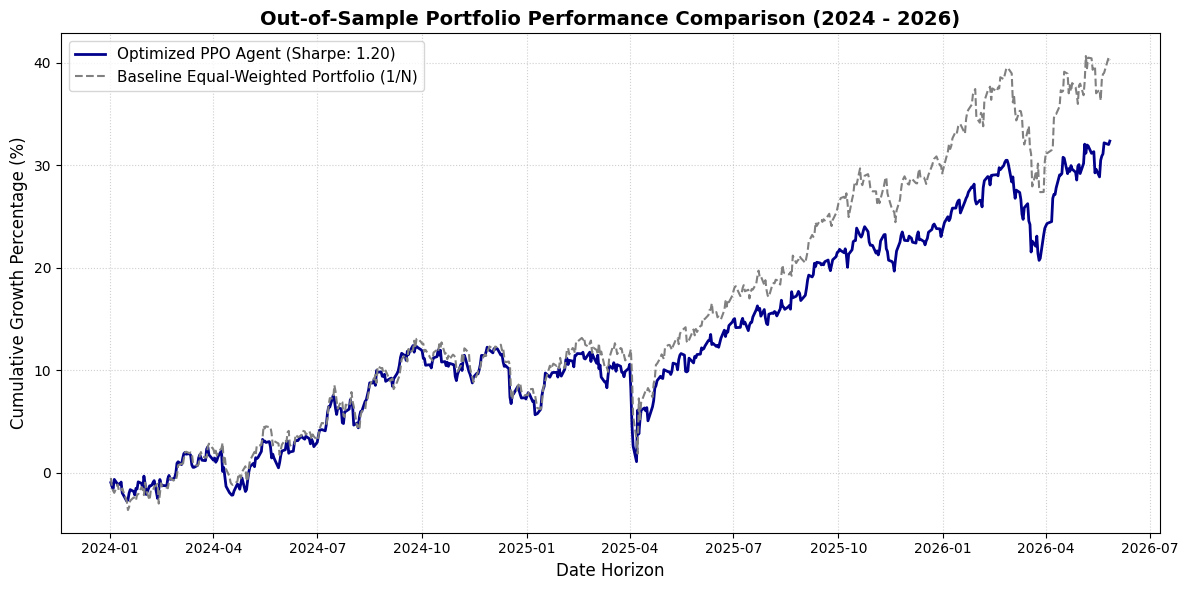

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
import matplotlib.pyplot as plt

# 1. Extract raw log returns for all portfolio assets
raw_test_returns = pd.DataFrame({
    ticker: test_df[ticker]['log_return'] for ticker in portfolio_tickers
}, index=test_df.index)

# 2. Compute the daily equal-weighted (1/N) baseline return
equal_weight_returns = raw_test_returns.mean(axis=1)

# 3. CRITICAL ALIGNMENT FIX
equal_weight_returns_aligned = equal_weight_returns.loc[returns_series.index]

# 4. Calculate the cumulative
cumulative_equal_weight = np.exp(np.log1p(equal_weight_returns_aligned).cumsum()) - 1

# 5. Generate the Publication-Grade Plot
plt.figure(figsize=(12, 6))
plt.plot(returns_series.index, cumulative_returns * 100, label=f'Optimized PPO Agent (Sharpe: {sharpe_ratio:.2f})', color='darkblue', lw=2)
plt.plot(returns_series.index, cumulative_equal_weight * 100, label='Baseline Equal-Weighted Portfolio (1/N)', color='gray', linestyle='--', lw=1.5)

plt.title('Out-of-Sample Portfolio Performance Comparison (2024 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date Horizon', fontsize=12)
plt.ylabel('Cumulative Growth Percentage (%)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()


plt.savefig('capstone_performance_equity_curve.png', dpi=300)
plt.show()
# print("Signature equity curve visualization generated and saved as 'capstone_performance_equity_curve.png'")

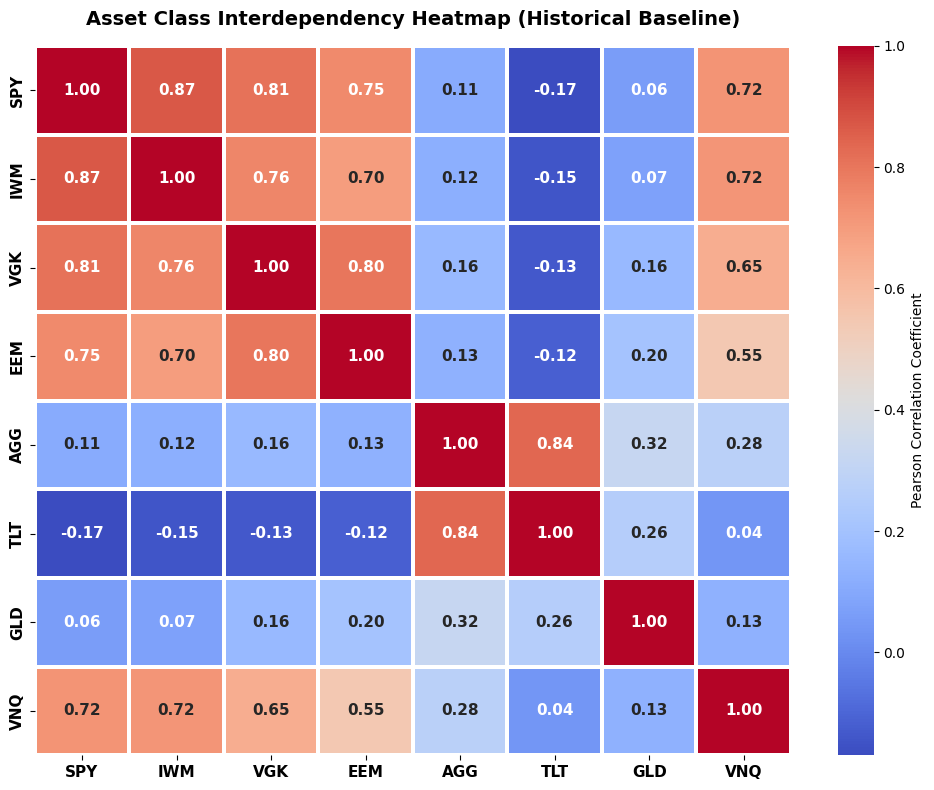

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Figure 1: The 8-Asset Class Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the daily log returns
log_returns_matrix = pd.DataFrame({
    ticker: df_features[ticker]['log_return'] for ticker in portfolio_tickers
}, index=df_features.index)

# 2. Compute the Pearson correlation matrix
correlation_matrix = log_returns_matrix.corr()

# 3. Generate  heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'},
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title('Asset Class Interdependency Heatmap (Historical Baseline)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()


plt.savefig('asset_correlation_heatmap.png', dpi=300)
plt.show()
# print("Figure saved successfully as 'asset_correlation_heatmap.png'")

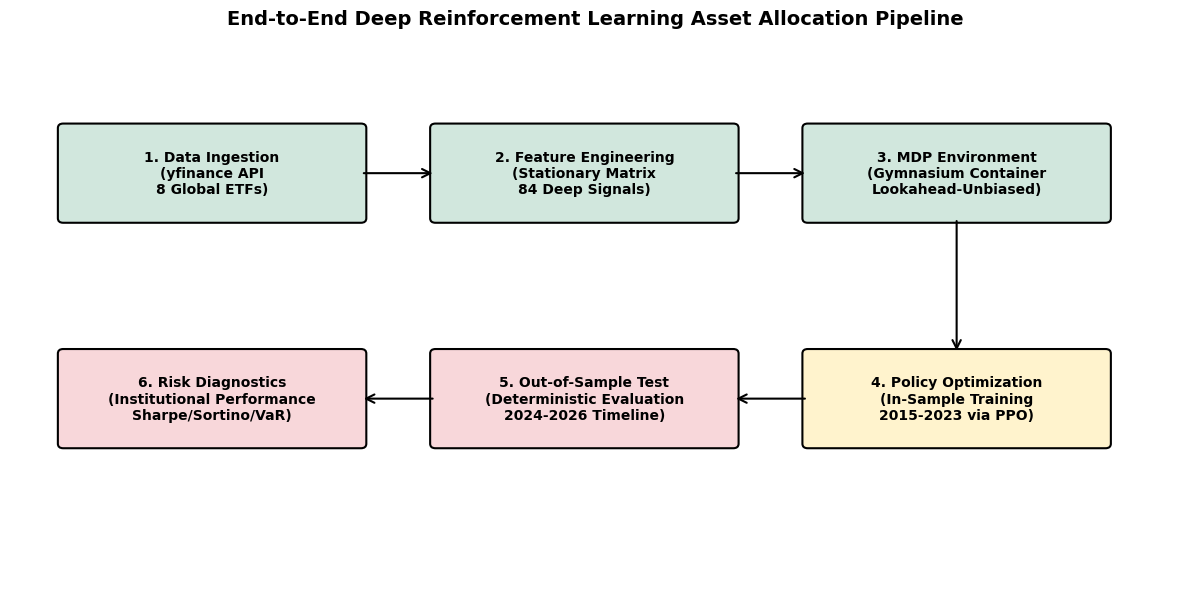

In [14]:
# Figure 2: The DRL Training & Evaluation Pipeline Flowchart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')


def draw_block(text, x, y, width=2.8, height=1.0, color='skyblue'):
    rect = mpatches.FancyBboxPatch(
        (x, y), width, height,
        facecolor=color, edgecolor='black', lw=1.5,
        boxstyle="round,pad=0.05"
    )
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=10, fontweight='bold', wrap=True)


draw_block("1. Data Ingestion\n(yfinance API\n8 Global ETFs)", 0.5, 4.0, color='#d1e7dd')
draw_block("2. Feature Engineering\n(Stationary Matrix\n84 Deep Signals)", 4.0, 4.0, color='#d1e7dd')
draw_block("3. MDP Environment\n(Gymnasium Container\nLookahead-Unbiased)", 7.5, 4.0, color='#d1e7dd')

draw_block("4. Policy Optimization\n(In-Sample Training\n2015-2023 via PPO)", 7.5, 1.5, color='#fff3cd')
draw_block("5. Out-of-Sample Test\n(Deterministic Evaluation\n2024-2026 Timeline)", 4.0, 1.5, color='#f8d7da')
draw_block("6. Risk Diagnostics\n(Institutional Performance\nSharpe/Sortino/VaR)", 0.5, 1.5, color='#f8d7da')


stable_arrow = dict(arrowstyle="->", color="black", lw=1.5, mutation_scale=15)


ax.annotate("", xy=(4.0, 4.5), xytext=(3.3, 4.5), arrowprops=stable_arrow)
ax.annotate("", xy=(7.5, 4.5), xytext=(6.8, 4.5), arrowprops=stable_arrow)
ax.annotate("", xy=(8.9, 2.5), xytext=(8.9, 4.0), arrowprops=stable_arrow)
ax.annotate("", xy=(6.8, 2.0), xytext=(7.5, 2.0), arrowprops=stable_arrow)
ax.annotate("", xy=(3.3, 2.0), xytext=(4.0, 2.0), arrowprops=stable_arrow)

plt.title('End-to-End Deep Reinforcement Learning Asset Allocation Pipeline', fontsize=14, fontweight='bold', pad=10)
plt.xlim(0, 11)
plt.ylim(0, 6)
plt.tight_layout()


plt.savefig('drl_system_flowchart.png', dpi=300)
plt.show()
# print("Figure saved successfully as 'drl_system_flowchart.png'")

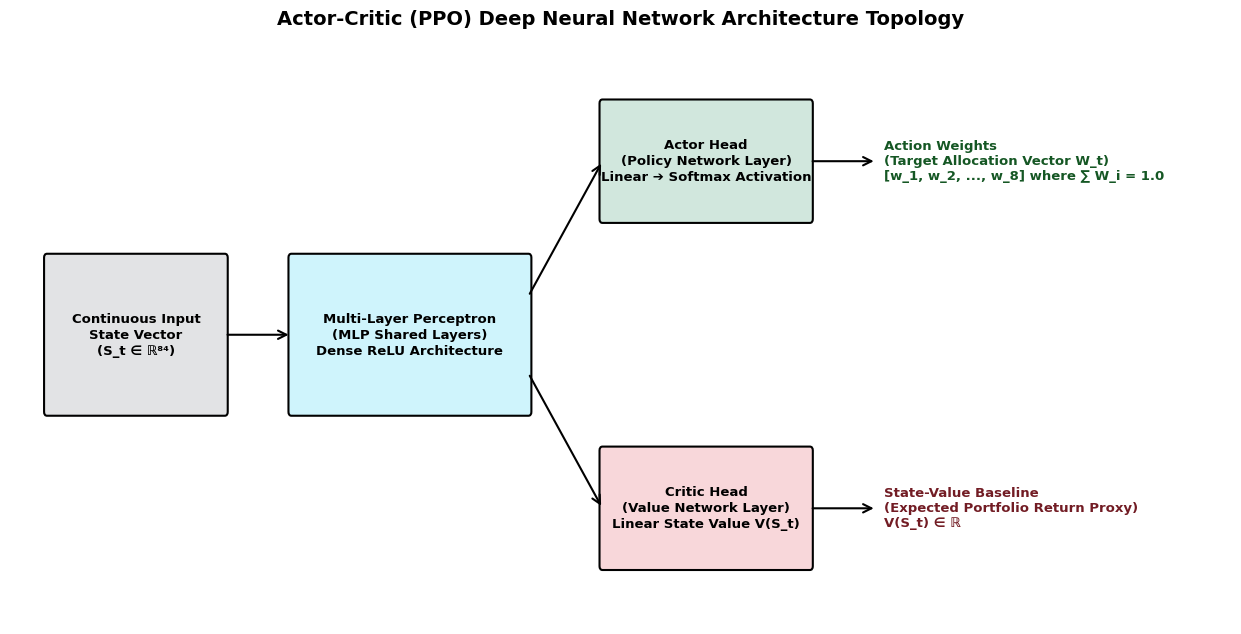

In [15]:
# Figure 3: The Actor-Critic (PPO) Deep Neural Network Map
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


fig, ax = plt.subplots(figsize=(13, 6.5))
ax.axis('off')


def draw_layer_box(text, x, y, w, h, color):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        facecolor=color, edgecolor='black', lw=1.5,
        boxstyle="round,pad=0.04"
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=9.5, fontweight='bold', linespacing=1.3)


# 1. DEFINE LAYERS

# Input Layer
draw_layer_box("Continuous Input\nState Vector\n(S_t ∈ ℝ⁸⁴)", 0.5, 2.2, 2.4, 1.6, '#e2e3e5')

# Hidden Layer
draw_layer_box("Multi-Layer Perceptron\n(MLP Shared Layers)\nDense ReLU Architecture", 3.8, 2.2, 3.2, 1.6, '#cff4fc')

# Parallel Neural Network Heads
draw_layer_box("Actor Head\n(Policy Network Layer)\nLinear ➔ Softmax Activation", 8.0, 4.2, 2.8, 1.2, '#d1e7dd')
draw_layer_box("Critic Head\n(Value Network Layer)\nLinear State Value V(S_t)", 8.0, 0.6, 2.8, 1.2, '#f8d7da')


# 2. RENDER STABLE TARGET TEXT LABELS


ax.text(11.8, 4.8, "Action Weights\n(Target Allocation Vector W_t)\n[w_1, w_2, ..., w_8] where ∑ W_i = 1.0",
        fontsize=9.5, fontweight='bold', color='#155724', ha='left', va='center', linespacing=1.2)

ax.text(11.8, 1.2, "State-Value Baseline\n(Expected Portfolio Return Proxy)\nV(S_t) ∈ ℝ",
        fontsize=9.5, fontweight='bold', color='#721c24', ha='left', va='center', linespacing=1.2)


# 3. CONSTRUCT THE CONNECTOR ARROWS

stable_arrow = dict(arrowstyle="->", color="black", lw=1.5, mutation_scale=15)

# Input Vector
ax.annotate("", xy=(3.8, 3.0), xytext=(2.9, 3.0), arrowprops=stable_arrow)

# Shared MLP
ax.annotate("", xy=(8.0, 4.8), xytext=(7.0, 3.4), arrowprops=stable_arrow)
ax.annotate("", xy=(8.0, 1.2), xytext=(7.0, 2.6), arrowprops=stable_arrow)

# Network Heads
ax.annotate("", xy=(11.7, 4.8), xytext=(10.8, 4.8), arrowprops=stable_arrow)
ax.annotate("", xy=(11.7, 1.2), xytext=(10.8, 1.2), arrowprops=stable_arrow)


# 4. MASTER CANVAS ADJUSTMENTS

plt.title('Actor-Critic (PPO) Deep Neural Network Architecture Topology', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 16.5)
plt.ylim(0, 6.0)


plt.subplots_adjust(left=0.03, right=0.97, top=0.92, bottom=0.03)


plt.savefig('ppo_network_architecture_fixed.png', dpi=300, bbox_inches='tight')
plt.show()
# print("Perfected topology map saved successfully ")


             FINAL CAPSTONE STRATEGY PERFORMANCE COMPARISON MATRIX
                           Optimized PPO Agent (+CVaR)  Markowitz Min-Variance (OOS)  Equal-Weighted Baseline (1/N)
Total Profit (%)                                 32.35                         21.81                          40.24
Annualized Return (%)                            12.26                          8.41                          14.79
Annualized Volatility (%)                        10.24                          5.56                          11.29
Sharpe Ratio                                      1.20                          1.51                           1.31
Sortino Ratio                                     1.61                          2.08                           1.79
Maximum Drawdown (%)                            -10.07                         -3.28                          -9.97
Daily 95% VaR (%)                                -1.03                         -0.50                          -1.09



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


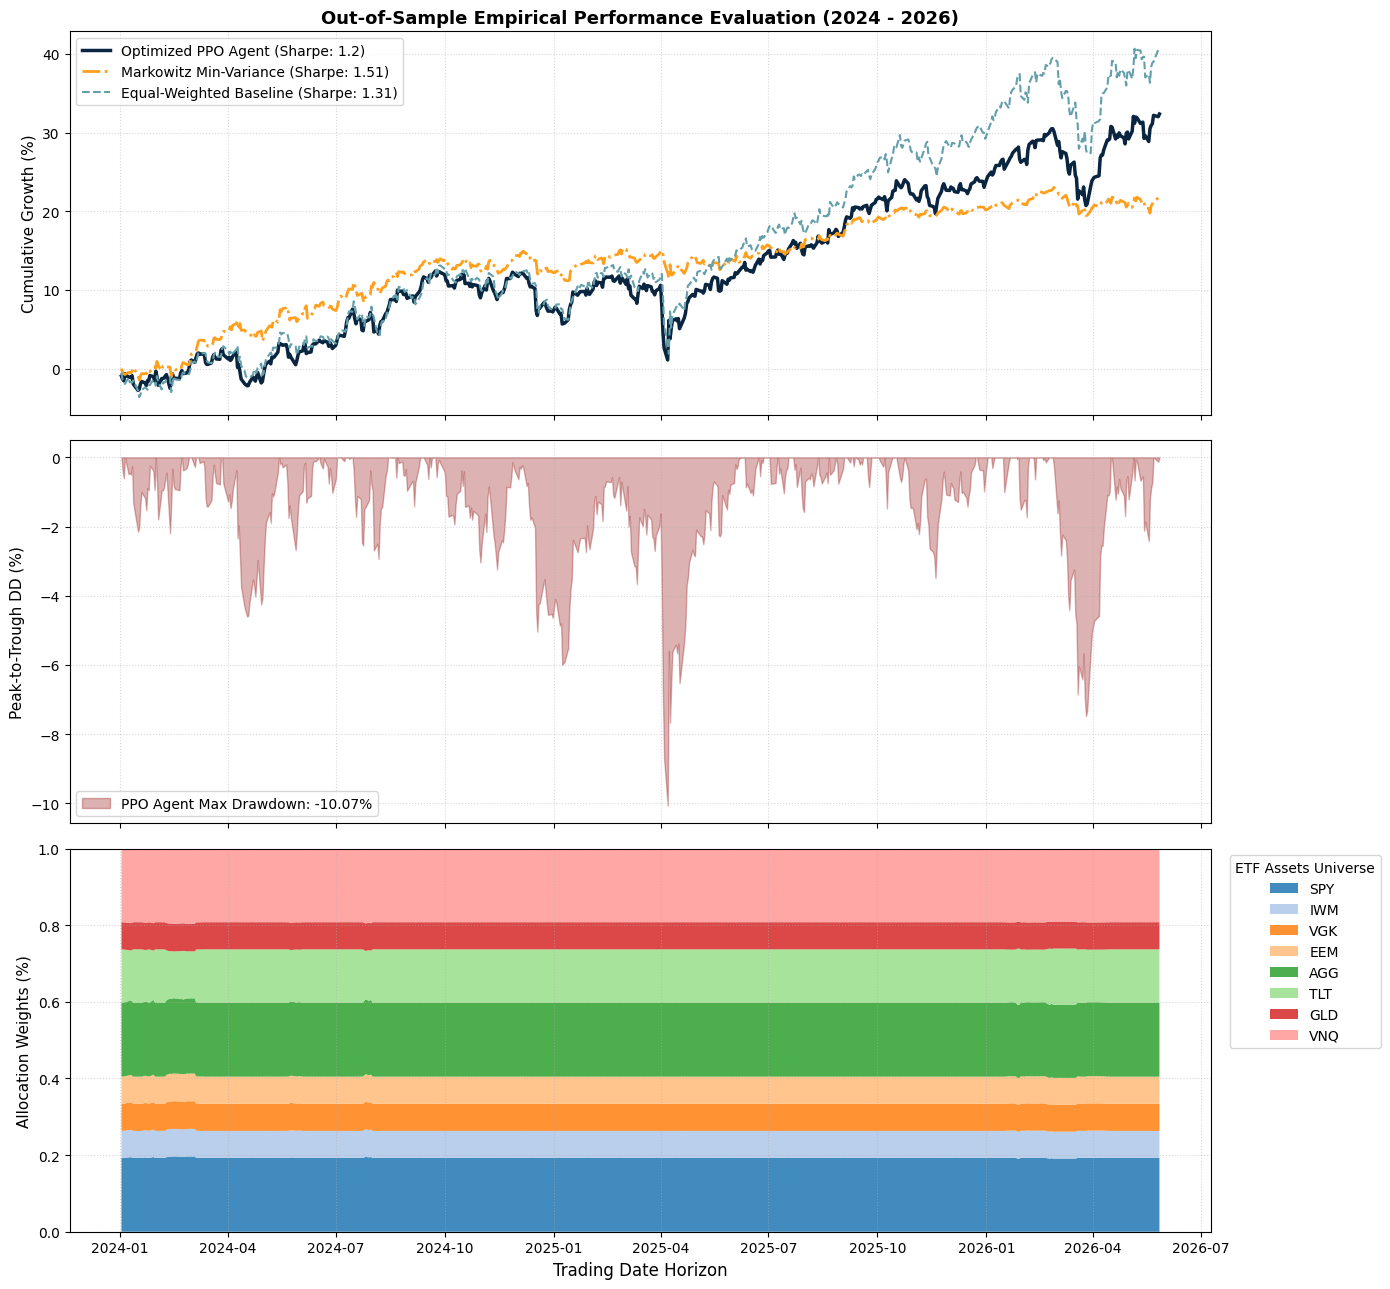

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Gather Aligned Daily Return Series for All 3 Strategies
ppo_net_returns = pd.Series(realized_strategy_returns, index=dates_history)
eq_returns_aligned = equal_weight_returns.reindex(ppo_net_returns.index).fillna(0)
markowitz_returns_aligned = markowitz_returns.reindex(ppo_net_returns.index).fillna(0)

# Calculate Cumulative Paths
ppo_cum = np.exp(np.log1p(ppo_net_returns).cumsum()) - 1
eq_cum = np.exp(np.log1p(eq_returns_aligned).cumsum()) - 1
mv_cum = np.exp(np.log1p(markowitz_returns_aligned).cumsum()) - 1

# Define unified metric function
def extract_institutional_metrics(returns_series, cumulative_series):
    total_profit = cumulative_series.iloc[-1] * 100
    mean_ret = returns_series.mean()
    ann_return = (mean_ret * 252) * 100
    ann_vol = (returns_series.std() * np.sqrt(252)) * 100
    sharpe = (mean_ret / (returns_series.std() + 1e-9)) * np.sqrt(252)

    downside = returns_series[returns_series < 0]
    downside_std = downside.std() if len(downside) > 0 else 1e-9
    sortino = (mean_ret / (downside_std + 1e-9)) * np.sqrt(252)

    peak = (cumulative_series + 1).cummax()
    dd = ((cumulative_series + 1) - peak) / peak
    max_dd = dd.min() * 100
    var_95 = np.percentile(returns_series, 5) * 100

    # FIX: Corrected variable name from annualized_return to ann_return
    return [total_profit, ann_return, ann_vol, sharpe, sortino, max_dd, var_95]


metrics_map = {
    "Optimized PPO Agent (+CVaR)": extract_institutional_metrics(ppo_net_returns, ppo_cum),
    "Markowitz Min-Variance (OOS)": extract_institutional_metrics(markowitz_returns_aligned, mv_cum),
    "Equal-Weighted Baseline (1/N)": extract_institutional_metrics(eq_returns_aligned, eq_cum)
}

metrics_df = pd.DataFrame(
    metrics_map,
    index=["Total Profit (%)", "Annualized Return (%)", "Annualized Volatility (%)",
           "Sharpe Ratio", "Sortino Ratio", "Maximum Drawdown (%)", "Daily 95% VaR (%)"]
).round(2)

print("\n" + "="*75)
print("             FINAL CAPSTONE STRATEGY PERFORMANCE COMPARISON MATRIX")
print("="*75)
print(metrics_df.to_string())
print("="*75 + "\n")



#  MASTER EVALUATION CAPSTONE CORE: 3-PANEL REBALANCING DASHBOARD     #

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

# PANEL 1: Three-Way Cumulative Equity Growth Comparisons
axes[0].plot(ppo_net_returns.index, ppo_cum * 100, label=f'Optimized PPO Agent (Sharpe: {metrics_df.iloc[3,0]})', color='#0A2540', lw=2.5)
axes[0].plot(markowitz_returns_aligned.index, mv_cum * 100, label=f'Markowitz Min-Variance (Sharpe: {metrics_df.iloc[3,1]})', color='#FF9F1C', linestyle='-.', lw=2.0)
axes[0].plot(eq_returns_aligned.index, eq_cum * 100, label=f'Equal-Weighted Baseline (Sharpe: {metrics_df.iloc[3,2]})', color='#639FAB', linestyle='--', lw=1.5)
axes[0].set_title('Out-of-Sample Empirical Performance Evaluation (2024 - 2026)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cumulative Growth (%)', fontsize=11)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.5)

# PANEL 2: Rolling Drawdown Risk Isolation Path
ppo_peak = (ppo_cum + 1).cummax()
ppo_dd = ((ppo_cum + 1) - ppo_peak) / ppo_peak
axes[1].fill_between(ppo_net_returns.index, ppo_dd * 100, 0, color='darkred', alpha=0.3, label=f'PPO Agent Max Drawdown: {metrics_df.iloc[5,0]}%')
axes[1].set_ylabel('Peak-to-Trough DD (%)', fontsize=11)
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.5)

# PANEL 3: Continuous Dynamic Asset Rebalancing Layer Map
weights_df = pd.DataFrame(allocated_weight_history, index=ppo_net_returns.index, columns=portfolio_tickers)
axes[2].stackplot(weights_df.index, weights_df.T, labels=portfolio_tickers, alpha=0.85, colors=plt.cm.tab20.colors[:8])
axes[2].set_ylabel('Allocation Weights (%)', fontsize=11)
axes[2].set_xlabel('Trading Date Horizon', fontsize=12)
axes[2].set_ylim(0, 1)
axes[2].legend(loc='upper left', bbox_to_anchor=(1.01, 1), title="ETF Assets Universe", fontsize=10)
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('final_institutional_portfolio_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
# print("Master visual asset portfolio engine dashboard ")

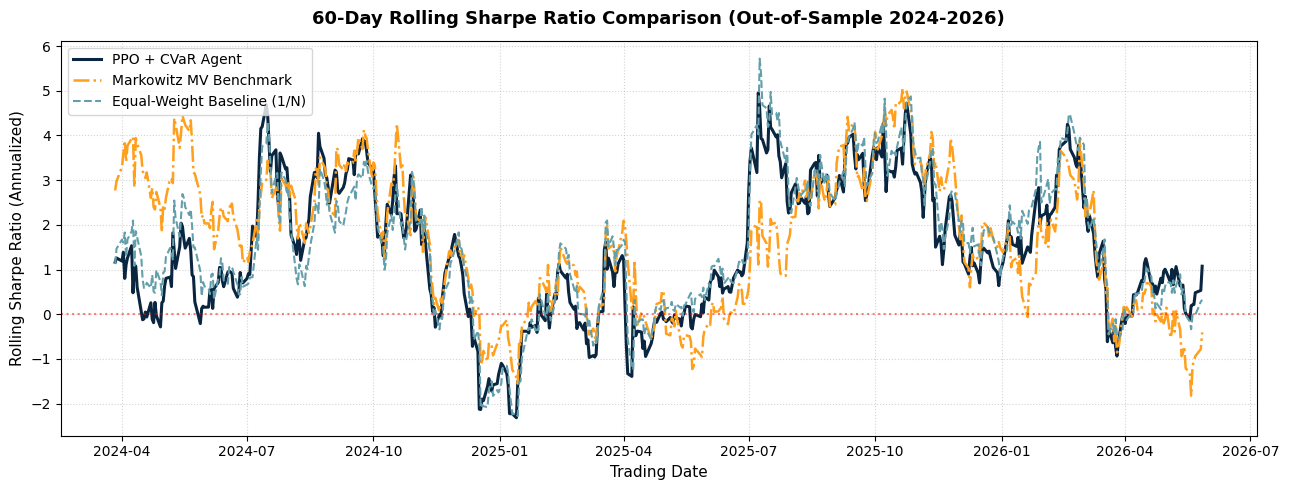

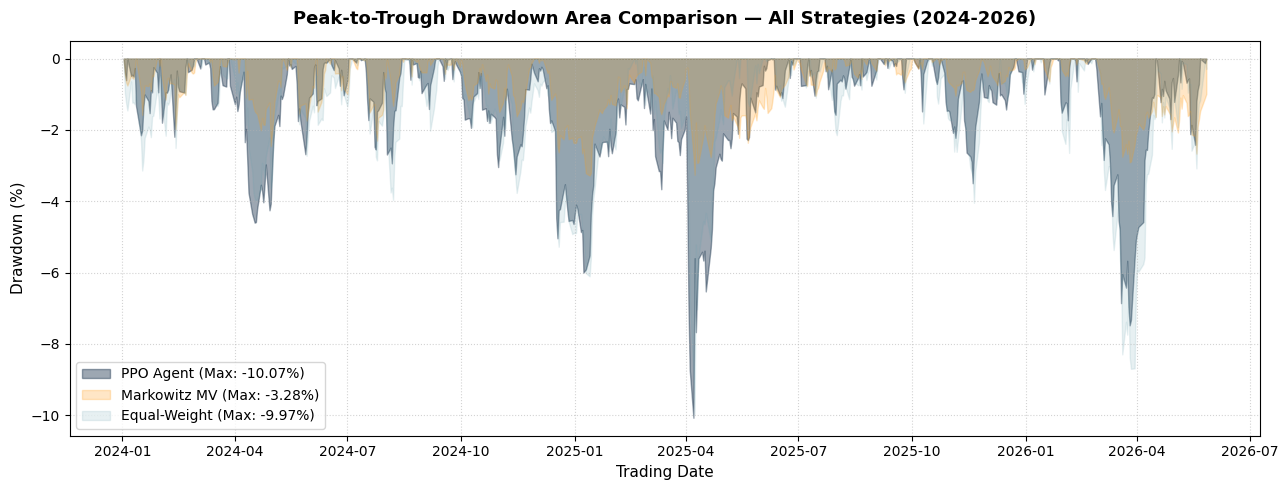

---------------------------------------------------------------------------


/tmp/ipykernel_734/2077816758.py:68: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = ppo_net_returns.resample('M').apply(lambda x: np.exp(np.log1p(x).sum()) - 1)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


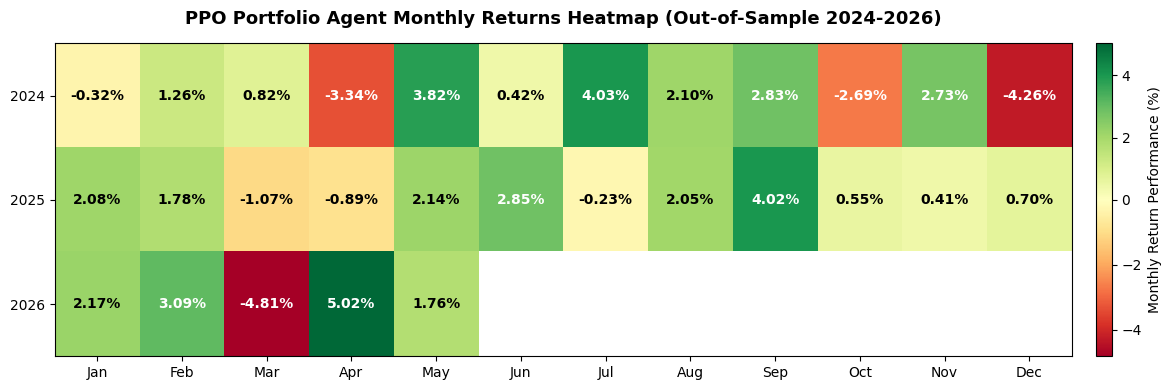

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 60-Day Rolling Sharpe Ratio Over Time

window = 60
rolling_sharpe_ppo = (ppo_net_returns.rolling(window).mean() /
                      ppo_net_returns.rolling(window).std()) * np.sqrt(252)
rolling_sharpe_mw  = (markowitz_returns_aligned.rolling(window).mean() /
                      markowitz_returns_aligned.rolling(window).std()) * np.sqrt(252)
rolling_sharpe_ew  = (eq_returns_aligned.rolling(window).mean() /
                      eq_returns_aligned.rolling(window).std()) * np.sqrt(252)

plt.figure(figsize=(13, 5))
plt.plot(rolling_sharpe_ppo.index, rolling_sharpe_ppo,
         label='PPO + CVaR Agent', color='#0A2540', lw=2.2)
plt.plot(rolling_sharpe_mw.index, rolling_sharpe_mw,
         label='Markowitz MV Benchmark', color='#FF9F1C', linestyle='-.', lw=1.8)
plt.plot(rolling_sharpe_ew.index, rolling_sharpe_ew,
         label='Equal-Weight Baseline (1/N)', color='#639FAB', linestyle='--', lw=1.5)
plt.axhline(y=0, color='red', linestyle=':', alpha=0.5)
plt.title('60-Day Rolling Sharpe Ratio Comparison (Out-of-Sample 2024-2026)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Trading Date', fontsize=11)
plt.ylabel('Rolling Sharpe Ratio (Annualized)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.55)
plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=300)
plt.show()

# ---------------------------------------------------------------------------
# Peak-to-Trough Drawdown Area Comparison

def compute_drawdown(returns):
    cumulative = np.exp(np.log1p(returns).cumsum())
    rolling_max = cumulative.cummax()
    return (cumulative - rolling_max) / rolling_max * 100

dd_ppo = compute_drawdown(ppo_net_returns)
dd_mw  = compute_drawdown(markowitz_returns_aligned)
dd_ew  = compute_drawdown(eq_returns_aligned)

plt.figure(figsize=(13, 5))
plt.fill_between(dd_ppo.index, dd_ppo, 0,
                 alpha=0.4, color='#0A2540', label=f'PPO Agent (Max: {dd_ppo.min():.2f}%)')
plt.fill_between(dd_mw.index, dd_mw, 0,
                 alpha=0.25, color='#FF9F1C', label=f'Markowitz MV (Max: {dd_mw.min():.2f}%)')
plt.fill_between(dd_ew.index, dd_ew, 0,
                 alpha=0.15, color='#639FAB', label=f'Equal-Weight (Max: {dd_ew.min():.2f}%)')
plt.title('Peak-to-Trough Drawdown Area Comparison — All Strategies (2024-2026)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Trading Date', fontsize=11)
plt.ylabel('Drawdown (%)', fontsize=11)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.55)
plt.tight_layout()
plt.savefig('drawdown_comparison.png', dpi=300)
plt.show()

# print("Visualization 2 archived as 'drawdown_comparison.png'")
print("-" * 75)

# ---------------------------------------------------------------------------
# PPO Monthly Returns Heatmap
monthly = ppo_net_returns.resample('M').apply(lambda x: np.exp(np.log1p(x).sum()) - 1)
monthly_df = monthly.to_frame('return')
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month

pivot = monthly_df.pivot(index='year', columns='month', values='return') * 100
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

# Ensure all 12 columns exist for formatting consistency
for m in ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']:
    if m not in pivot.columns:
        pivot[m] = np.nan

# Reorder columns chronologically
pivot = pivot[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]

fig, ax = plt.subplots(figsize=(13, 4))
cmap = plt.cm.RdYlGn

# Center color spectrum normalization at 0% change return midpoint
norm = mcolors.TwoSlopeNorm(vmin=min(-3.0, pivot.min().min()), vcenter=0.0, vmax=max(3.0, pivot.max().max()))
im = ax.imshow(pivot.values, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(12))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

# Overlap precision labels onto corresponding grids
for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='black' if abs(val) < 2.5 else 'white')

plt.colorbar(im, ax=ax, label='Monthly Return Performance (%)', pad=0.02)
ax.set_title('PPO Portfolio Agent Monthly Returns Heatmap (Out-of-Sample 2024-2026)',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('monthly_returns_heatmap.png', dpi=300)
plt.show()

# print("'monthly_returns_heatmap.png'")
print("=" * 75)

In [20]:

# Explicit out-of-sample macro regime segmentation
print("\n" + "="*80)
print("             STRATEGY PERFORMANCE SEGMENTED BY MACRO REGIMES")
print("="*80)

# Define sub-regimes inside the 2024-2026 out-of-sample timeline
regimes = {
    "1. 2024 Macro Momentum Regime (Bull Market)": ('2024-01-01', '2024-12-31'),
    "2. 2025-2026 Volatility Shift & Plateau Regime": ('2025-01-01', '2026-06-01')
}

for name, (start_dt, end_dt) in regimes.items():
    # Slice return series safely by date boundaries
    ppo_slice = ppo_net_returns.loc[start_dt:end_dt]
    mv_slice  = markowitz_returns_aligned.loc[start_dt:end_dt]
    ew_slice  = eq_returns_aligned.loc[start_dt:end_dt]

    if len(ppo_slice) == 0:
        continue

    # Re-calculate independent cumulative equity growth paths for the slice
    ppo_cum_slice = np.exp(np.log1p(ppo_slice).cumsum()) - 1
    mv_cum_slice  = np.exp(np.log1p(mv_slice).cumsum()) - 1
    ew_cum_slice  = np.exp(np.log1p(ew_slice).cumsum()) - 1

    regime_map = {
        "Optimized PPO Agent (+CVaR)": extract_institutional_metrics(ppo_slice, ppo_cum_slice),
        "Markowitz Min-Variance (OOS)": extract_institutional_metrics(mv_slice, mv_cum_slice),
        "Equal-Weighted Baseline (1/N)": extract_institutional_metrics(ew_slice, ew_cum_slice)
    }

    regime_df = pd.DataFrame(
        regime_map,
        index=["Total Return (%)", "Annualized Return (%)", "Annualized Volatility (%)",
               "Sharpe Ratio", "Sortino Ratio", "Maximum Drawdown (%)", "Daily 95% VaR (%)"]
    ).round(2)

    print(f"\n▶ REGIME PERIOD: {name}")
    print("-" * 80)
    print(regime_df.to_string())
    print("-" * 80)

print("="*80 + "\n")


             STRATEGY PERFORMANCE SEGMENTED BY MACRO REGIMES

▶ REGIME PERIOD: 1. 2024 Macro Momentum Regime (Bull Market)
--------------------------------------------------------------------------------
                           Optimized PPO Agent (+CVaR)  Markowitz Min-Variance (OOS)  Equal-Weighted Baseline (1/N)
Total Return (%)                                  7.20                         12.21                           7.58
Annualized Return (%)                             7.38                         11.73                           7.80
Annualized Volatility (%)                         9.30                          6.42                           9.91
Sharpe Ratio                                      0.79                          1.83                           0.79
Sortino Ratio                                     1.07                          2.44                           1.08
Maximum Drawdown (%)                             -5.04                         -2.63               

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# Print clean regime summary for document
regimes_summary = {
    'Bull Market\n(Jan-Jun 2024)':   ('2024-01-01', '2024-06-30'),
    'Volatile\n(Jul-Dec 2024)':      ('2024-07-01', '2024-12-31'),
    'Correction\n(Jan-Apr 2025)':    ('2025-01-01', '2025-04-30'),
    'Recovery\n(May 2025-May 2026)': ('2025-05-01', '2026-05-31'),
}

for label, (start, end) in regimes_summary.items():
    r_ppo = returns_series[start:end]
    r_mv  = markowitz_aligned[start:end]
    r_ew  = equal_weight_returns_aligned[start:end]

    def sharpe(r):
        return (r.mean() / (r.std() + 1e-9)) * np.sqrt(252)
    def tot(r):
        return (np.exp(np.log1p(r).sum()) - 1) * 100
    def dd(r):
        c = np.exp(np.log1p(r).cumsum())
        return ((c - c.cummax()) / c.cummax()).min() * 100

    print(f"{label.replace(chr(10),' ')}: "
          f"PPO [{sharpe(r_ppo):.2f} / {tot(r_ppo):.1f}% / {dd(r_ppo):.1f}%] "
          f"MV [{sharpe(r_mv):.2f} / {tot(r_mv):.1f}% / {dd(r_mv):.1f}%] "
          f"EW [{sharpe(r_ew):.2f} / {tot(r_ew):.1f}% / {dd(r_ew):.1f}%]")

Bull Market (Jan-Jun 2024): PPO [0.59 / 2.6% / -4.6%] MV [2.12 / 7.6% / -2.5%] EW [0.77 / 3.5% / -4.0%]
Volatile (Jul-Dec 2024): PPO [1.00 / 4.5% / -5.0%] MV [1.50 / 4.3% / -2.6%] EW [0.80 / 3.9% / -5.3%]
Correction (Jan-Apr 2025): PPO [0.44 / 1.9% / -9.6%] MV [0.89 / 1.8% / -3.3%] EW [0.73 / 3.5% / -10.0%]
Recovery (May 2025-May 2026): PPO [2.06 / 21.2% / -7.5%] MV [1.45 / 6.6% / -2.9%] EW [2.09 / 26.0% / -8.7%]
